# Challenge 1: datos y análisis exploratorio

Tu primera responsabilidad es preparar una fuente de datos confiable para el proyecto de clasificación de vinos.

**Entrada:** `data/raw/wine.csv`  
**Salidas:** `data/processed/train.csv`, `data/processed/test.csv` y `artifacts/data_contract.json`

> El conjunto de test se crea aquí, pero no debe explorarse ni utilizarse después del split.

## Objetivos

- cargar y validar datos externos;
- identificar problemas básicos de calidad;
- crear un split reproducible y estratificado;
- realizar EDA únicamente sobre entrenamiento;
- guardar datos y metadatos para la siguiente etapa.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga y profiling

In [5]:
import shutil

DATA_PATH = RAW_DATA_DIR / "wine.csv"

# Si el archivo no está en data/raw, lo buscamos en Drive y lo copiamos allí
if not DATA_PATH.exists():
    from google.colab import drive
    drive.mount("/content/drive")

    matches = list(Path("/content/drive/MyDrive").rglob("wine.csv"))
    if not matches:
        raise FileNotFoundError("No encontré wine.csv en tu Drive. Revisa que el archivo exista.")
    if len(matches) > 1:
        print("Se encontraron varios wine.csv, usando el primero:", *matches, sep="\n- ")

    RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copy(matches[0], DATA_PATH)

df = pd.read_csv(DATA_PATH)

# Validación mínima: el resto del notebook asume una columna "target"
assert "target" in df.columns, f"No existe la columna 'target'. Columnas: {list(df.columns)}"

print("Cargado:", DATA_PATH)
df.head()

Mounted at /content/drive
Cargado: /content/data/raw/wine.csv


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
# --- Forma y tipos ---
print("Forma (filas, columnas):", df.shape)
print("\nTipos de datos:")
print(df.dtypes.to_string())

# --- Nulos ---
nulls = df.isna().sum()
print("\nNulos por columna:")
print(nulls[nulls > 0].to_string() if nulls.any() else "Sin valores nulos")

# --- Duplicados ---
n_dup = df.duplicated().sum()
print(f"\nFilas duplicadas: {n_dup}")

# --- Distribución del target ---
target_counts = df["target"].value_counts().sort_index()
target_pct = (df["target"].value_counts(normalize=True).sort_index() * 100).round(1)
print("\nDistribución del target:")
print(pd.DataFrame({"n": target_counts, "%": target_pct}).to_string())

# --- Chequeos básicos de calidad ---
feature_cols = [c for c in df.columns if c != "target"]
non_numeric = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
print("\nFeatures no numéricas:", non_numeric if non_numeric else "ninguna")
print("Valores negativos en features:", int((df[feature_cols] < 0).sum().sum()))
print("Valores infinitos en features:", int(np.isinf(df[feature_cols]).sum().sum()))

# --- Rangos por variable (solo para detectar valores imposibles) ---
df[feature_cols].describe().T[["min", "mean", "max"]].round(2)

Forma (filas, columnas): (178, 14)

Tipos de datos:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64

Nulos por columna:
Sin valores nulos

Filas duplicadas: 0

Distribución del target:
         n     %
target          
0       59  33.1
1       71  39.9
2       48  27.0

Features no numéricas: ninguna
Valores negativos en features: 0
Valores infinitos en features: 0


,min,mean,max
alcohol,11.03,13.00,14.83
malic_acid,0.74,2.34,5.80
ash,1.36,2.37,3.23
alcalinity_of_ash,10.60,19.49,30.00
magnesium,70.00,99.74,162.00
total_phenols,0.98,2.30,3.88
flavanoids,0.34,2.03,5.08
nonflavanoid_phenols,0.13,0.36,0.66
proanthocyanins,0.41,1.59,3.58
color_intensity,1.28,5.06,13.00


**Conclusión de calidad:**

> Describe brevemente qué encontraste y qué decisión tomaste.

El dataset tiene 178 filas, 13 features numéricas y la columna target con 3 clases. No hay nulos, duplicados, valores negativos ni infinitos, por lo que no se requiere limpieza. Las clases están moderadamente desbalanceadas (59 / 71 / 48), así que usaré un split estratificado. Las features tienen escalas muy distintas, algo a considerar en el modelado. Decisión: conservar los datos tal cual y pasar al split.

## 2. Split train/test

In [7]:
TEST_SIZE = 0.2

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["target"],
    random_state=RANDOM_STATE,
)

# Solo para confirmar que la estratificación funcionó (proporciones de clase)
print(pd.DataFrame({
    "original_%": (df["target"].value_counts(normalize=True).sort_index() * 100).round(1),
    "train_%": (train_df["target"].value_counts(normalize=True).sort_index() * 100).round(1),
    "test_%": (test_df["target"].value_counts(normalize=True).sort_index() * 100).round(1),
}).to_string())

        original_%  train_%  test_%
target                             
0             33.1     33.1    33.3
1             39.9     40.1    38.9
2             27.0     26.8    27.8


In [8]:
# Verificación del split
assert len(train_df) + len(test_df) == len(df)
assert set(train_df.index).isdisjoint(set(test_df.index))
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (142, 14)
Test: (36, 14)


## 3. EDA sobre entrenamiento

Incluye:

- distribución de clases;
- distribuciones o boxplots de variables relevantes;
- correlaciones;
- tres hallazgos que puedan influir en el modelado.

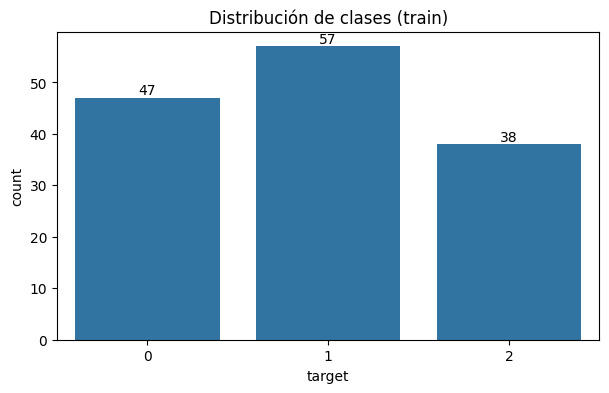

Ranking de features por F-score (ANOVA, train):
flavanoids                      224.8
proline                         161.5
od280/od315_of_diluted_wines    144.8
color_intensity                 103.9
alcohol                          98.5
hue                              79.5
total_phenols                    72.3
malic_acid                       29.1
alcalinity_of_ash                27.5
proanthocyanins                  23.3
nonflavanoid_phenols             20.8
ash                              12.9
magnesium                         9.2


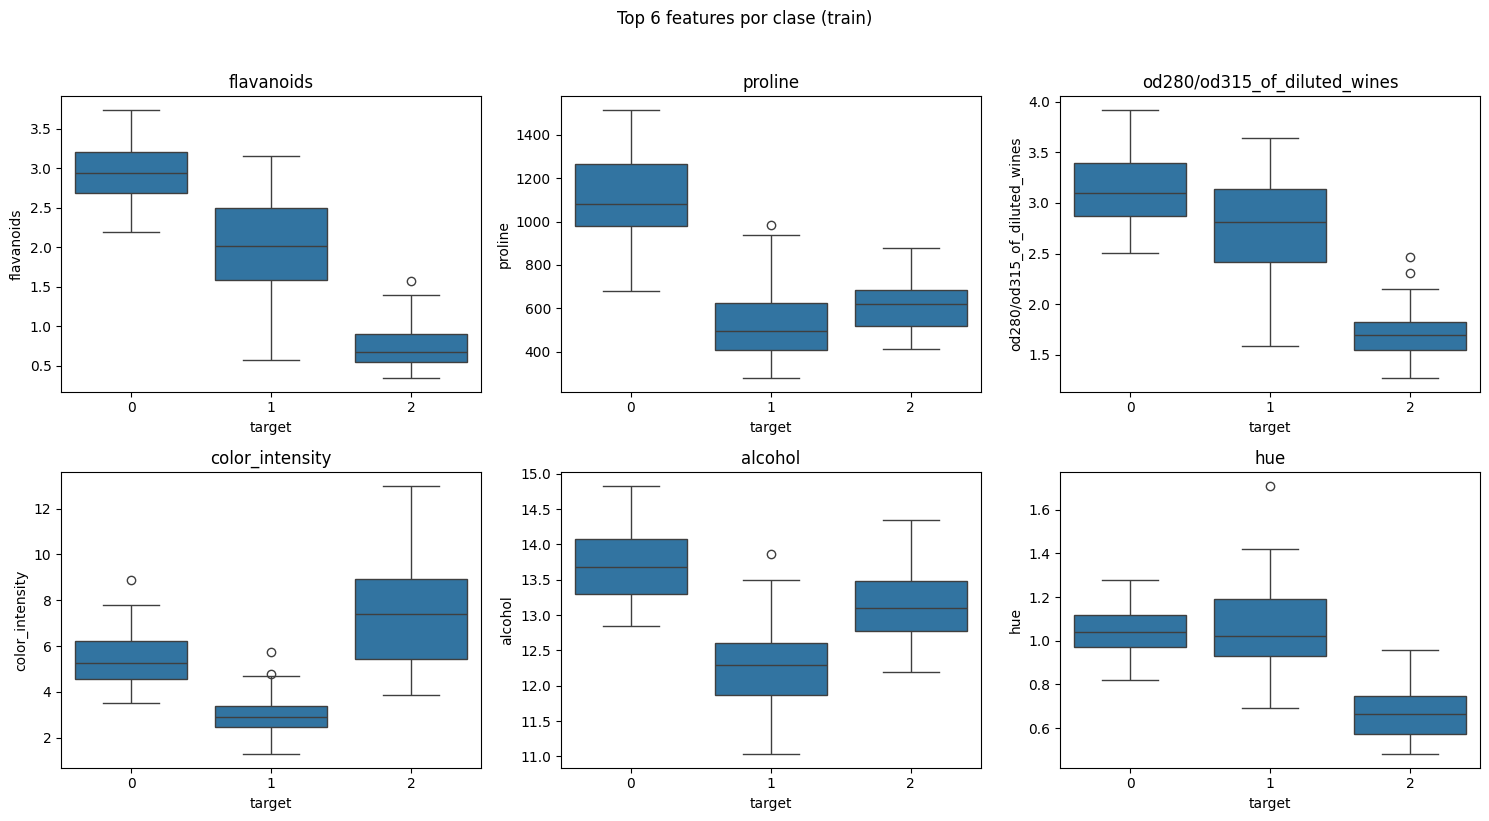

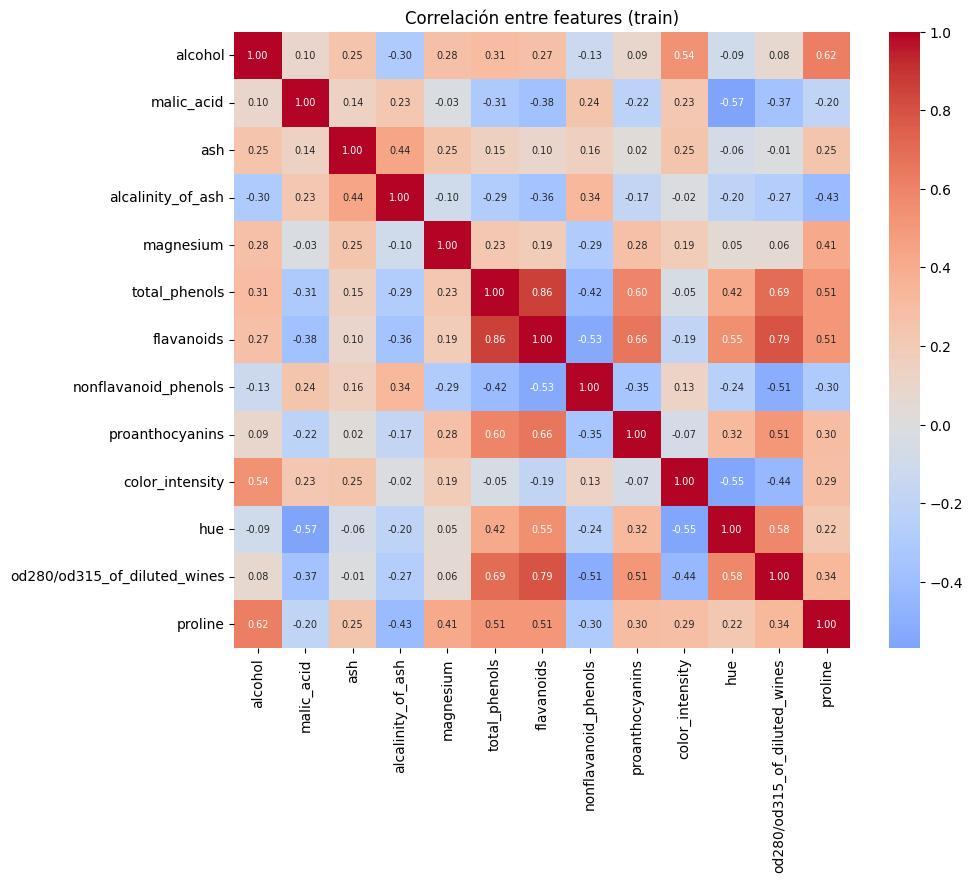


Pares con |r| > 0.6:
      level_0                      level_1    r
total_phenols                   flavanoids 0.86
   flavanoids od280/od315_of_diluted_wines 0.79
total_phenols od280/od315_of_diluted_wines 0.69
   flavanoids              proanthocyanins 0.66
      alcohol                      proline 0.62

Outliers por IQR (train):
alcalinity_of_ash    3
magnesium            3
ash                  2
color_intensity      2
proanthocyanins      2
malic_acid           1
hue                  1

Desviación estándar por feature (escalas):
proline                         301.50
magnesium                        14.94
alcalinity_of_ash                 3.38
color_intensity                   2.33
malic_acid                        1.10
flavanoids                        0.95
alcohol                           0.80
od280/od315_of_diluted_wines      0.69
total_phenols                     0.62
proanthocyanins                   0.58
ash                               0.27
hue                          

In [9]:
from sklearn.feature_selection import f_classif

feature_cols = [c for c in train_df.columns if c != "target"]
X_tr, y_tr = train_df[feature_cols], train_df["target"]

# ---------- 1. Distribución de clases ----------
fig, ax = plt.subplots()
sns.countplot(x="target", data=train_df, ax=ax)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
ax.set_title("Distribución de clases (train)")
plt.show()

# ---------- 2. Boxplots de las variables más discriminantes ----------
# Ranking por F-score de ANOVA, calculado solo con train
f_scores, _ = f_classif(X_tr, y_tr)
ranking = pd.Series(f_scores, index=feature_cols).sort_values(ascending=False)
print("Ranking de features por F-score (ANOVA, train):")
print(ranking.round(1).to_string())

top_features = ranking.index[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), top_features):
    sns.boxplot(x="target", y=col, data=train_df, ax=ax)
    ax.set_title(col)
plt.suptitle("Top 6 features por clase (train)", y=1.02)
plt.tight_layout()
plt.show()

# ---------- 3. Matriz de correlación ----------
corr = X_tr.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, square=True)
plt.title("Correlación entre features (train)")
plt.show()

# Pares más correlacionados (|r| > 0.6)
pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
             .stack()
             .rename("r")
             .reset_index()
             .query("abs(r) > 0.6")
             .sort_values("r", key=abs, ascending=False))
print("\nPares con |r| > 0.6:")
print(pairs.round(2).to_string(index=False))

# ---------- 4. Apoyo para hallazgos: outliers y escalas ----------
q1, q3 = X_tr.quantile(0.25), X_tr.quantile(0.75)
iqr = q3 - q1
outliers = ((X_tr < q1 - 1.5 * iqr) | (X_tr > q3 + 1.5 * iqr)).sum()
print("\nOutliers por IQR (train):")
print(outliers[outliers > 0].sort_values(ascending=False).to_string())

print("\nDesviación estándar por feature (escalas):")
print(X_tr.std().round(2).sort_values(ascending=False).to_string())

**Hallazgos:**

Unas pocas variables distinguen mejor las clases que las demás. Según el F-score de ANOVA, flavanoids (224.8), proline (161.5) y od280/od315_of_diluted_wines (144.8) son las que más diferencian las clases, mientras que magnesium (9.2) y ash (12.9) casi no lo hacen. Los boxplots lo confirman: flavanoids ordena las tres clases (0 > 1 > 2), proline separa la clase 0 de las otras dos, y color_intensity identifica la clase 1 (valores bajos). Sin embargo, ninguna variable separa las tres clases por sí sola, por lo que el modelo debe combinar varias.

Hay multicolinealidad entre variables relacionadas con fenoles. total_phenols–flavanoids (0.86), flavanoids–od280/od315 (0.79) y total_phenols–od280/od315 (0.69) son redundantes. En modelos lineales puede volver inestables los coeficientes, por lo que habrá que usar regularización o seleccionar variables. Los árboles y ensambles son poco sensibles a esto.

Las escalas son muy distintas y hay pocos atípicos leves. La desviación estándar de proline (301.5) es unas 2500 veces la de nonflavanoid_phenols (0.12). Los modelos basados en distancia o regularización necesitan estandarización, ajustada solo con train y dentro de un Pipeline. Los atípicos son pocos (máximo 3 por variable), así que no los eliminaría con solo 142 observaciones; basta con un escalado robusto o un modelo tolerante a ellos.

## 4. Persistencia de datos y contrato

In [10]:
# Reiniciar índices y guardar sin índice
train_out = train_df.reset_index(drop=True)
test_out = test_df.reset_index(drop=True)

train_out.to_csv(PROCESSED_DATA_DIR / "train.csv", index=False)
test_out.to_csv(PROCESSED_DATA_DIR / "test.csv", index=False)

# Contrato de datos
feature_cols = [c for c in train_out.columns if c != "target"]

data_contract = {
    "target": "target",
    "features": feature_cols,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "n_train": int(len(train_out)),
    "n_test": int(len(test_out)),
    "classes": sorted(int(c) for c in train_out["target"].unique()),
}

with open(ARTIFACTS_DIR / "data_contract.json", "w", encoding="utf-8") as f:
    json.dump(data_contract, f, indent=2, ensure_ascii=False)

print(json.dumps(data_contract, indent=2, ensure_ascii=False))

{
  "target": "target",
  "features": [
    "alcohol",
    "malic_acid",
    "ash",
    "alcalinity_of_ash",
    "magnesium",
    "total_phenols",
    "flavanoids",
    "nonflavanoid_phenols",
    "proanthocyanins",
    "color_intensity",
    "hue",
    "od280/od315_of_diluted_wines",
    "proline"
  ],
  "random_state": 42,
  "test_size": 0.2,
  "n_train": 142,
  "n_test": 36,
  "classes": [
    0,
    1,
    2
  ]
}


In [11]:
# Verificación de entrega
assert (PROCESSED_DATA_DIR / "train.csv").exists()
assert (PROCESSED_DATA_DIR / "test.csv").exists()
assert (ARTIFACTS_DIR / "data_contract.json").exists()
print("Challenge 1 completado.")

Challenge 1 completado.


In [12]:
import shutil

print("Carpeta del proyecto:", PROJECT_DIR)
for p in (PROCESSED_DATA_DIR / "train.csv",
          PROCESSED_DATA_DIR / "test.csv",
          ARTIFACTS_DIR / "data_contract.json"):
    print(("OK  " if p.exists() else "FALTA"), p)

# Si el proyecto está en /content (temporal), copiamos todo a Drive
if str(PROJECT_DIR).startswith("/content") and not str(PROJECT_DIR).startswith("/content/drive"):
    from google.colab import drive
    drive.mount("/content/drive")

    # Cambia TU_CARPETA por la carpeta donde está tu notebook
    DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/TU_CARPETA")

    for sub in ("data/processed", "artifacts"):
        shutil.copytree(PROJECT_DIR / sub, DRIVE_PROJECT_DIR / sub, dirs_exist_ok=True)
    print("\nCopiado a:", DRIVE_PROJECT_DIR)
else:
    print("\nLos archivos ya están en Drive, no hace falta copiar.")

Carpeta del proyecto: /content
OK   /content/data/processed/train.csv
OK   /content/data/processed/test.csv
OK   /content/artifacts/data_contract.json
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Copiado a: /content/drive/MyDrive/TU_CARPETA


## Checklist

- [ ] Cargué el CSV desde `data/raw`.
- [ ] Revisé calidad y distribución de la clase.
- [ ] Realicé un split estratificado.
- [ ] No exploré el conjunto de test.
- [ ] Guardé los tres artefactos requeridos.